# Clasificación de Lesiones Cutáneas: Exploración de Arquitecturas Deep Learning

---

## Objetivo

Este notebook documenta un proceso iterativo de experimentación con diferentes arquitecturas de redes neuronales para clasificar imágenes dermatoscópicas. Seguiremos una **secuencia de decisiones** basada en resultados empíricos:

1. **CNN desde cero** → Establecer baseline
2. **ResNet50 sin warmup** → Ver por qué falla
3. **ResNet50 con warmup + fine-tuning** → Mejorar con buenas prácticas
4. **ResNet18 con warmup + fine-tuning** → Probar arquitectura más ligera
5. **EfficientNet-B0 con warmup + fine-tuning** → Arquitectura moderna y eficiente
6. **MobileNetV2 con warmup + fine-tuning** → Alternativa ligera
7. **Análisis comparativo** → Identificar fortalezas y debilidades
8. **Ensemble** → Combinar modelos complementarios

### Estrategia de Transfer Learning

Para todos los modelos preentrenados aplicamos:
- **Fase 1 (Warmup)**: Backbone congelado, solo entrenar cabeza, LR=1e-3, 5 épocas
- **Fase 2 (Fine-tuning)**: Todo descongelado, LR=1e-5, 15 épocas

### Dataset

| Clase | Nombre | Tipo | Importancia Clínica |
|-------|--------|------|--------------------|
| ACK | Queratosis actínica | Precanceroso | Alta |
| BCC | Carcinoma basocelular | Maligno | Alta |
| **MEL** | **Melanoma** | **Maligno** | **Crítica** |
| NEV | Nevus | Benigno | Baja |
| SCC | Carcinoma espinocelular | Maligno | Alta |
| SEK | Queratosis seborreica | Benigno | Baja |

---
# PARTE 1: CONFIGURACIÓN Y PREPARACIÓN DE DATOS

## 1.1 Importaciones y Configuración

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms, models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
import seaborn as sns
from collections import Counter
import copy, time, warnings
warnings.filterwarnings('ignore')

# Configuración global
CONFIG = {
    'data_path': 'Datos/images',
    'batch_size': 32,
    'img_size': 224,
    'seed': 42
}

# ============================================
# CONFIGURACIÓN GPU (CUDA) - OBLIGATORIO
# ============================================
if not torch.cuda.is_available():
    raise RuntimeError("ERROR: CUDA no disponible. Este notebook requiere GPU.")

DEVICE = torch.device('cuda')
torch.cuda.set_device(0)

# Reproducibilidad en GPU
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
torch.cuda.manual_seed(CONFIG['seed'])
torch.cuda.manual_seed_all(CONFIG['seed'])
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

# Limpiar caché GPU
torch.cuda.empty_cache()

# Info GPU
print("="*60)
print("GPU CONFIGURADA CORRECTAMENTE")
print("="*60)
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Memoria Total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"CUDA Version: {torch.version.cuda}")
print(f"PyTorch Version: {torch.__version__}")
print("="*60)

# Diccionario para guardar resultados de todos los modelos
RESULTS = {}

GPU CONFIGURADA CORRECTAMENTE
Device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Memoria Total: 8.59 GB
CUDA Version: 12.8
PyTorch Version: 2.9.1+cu128


## 1.2 Clases y Funciones Reutilizables

Definimos utilidades comunes para evitar repetición de código.

In [29]:
class TransformSubset(torch.utils.data.Dataset):
    """Aplica transformaciones a un Subset."""
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    
    def __getitem__(self, idx):
        x, y = self.subset[idx]
        return self.transform(x) if self.transform else x, y
    
    def __len__(self):
        return len(self.subset)


class Trainer:
    """Clase unificada para entrenar cualquier modelo en GPU."""
    
    def __init__(self, model, device=DEVICE):
        self.model = model.to(device)
        self.device = device
        self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
        self.best_acc = 0.0
        self.best_weights = copy.deepcopy(model.state_dict())
        
        # Verificar que el modelo está en GPU
        assert next(model.parameters()).is_cuda, "ERROR: Modelo no está en GPU"
    
    def _run_epoch(self, loader, criterion, optimizer=None):
        is_train = optimizer is not None
        self.model.train() if is_train else self.model.eval()
        total_loss, total_correct, total_samples = 0.0, 0, 0
        
        with torch.set_grad_enabled(is_train):
            for inputs, labels in loader:
                # Mover a GPU con non_blocking para mejor rendimiento
                inputs = inputs.to(self.device, non_blocking=True)
                labels = labels.to(self.device, non_blocking=True)
                
                if is_train: optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = criterion(outputs, labels)
                if is_train:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    optimizer.step()
                total_loss += loss.item() * inputs.size(0)
                total_correct += (outputs.argmax(1) == labels).sum().item()
                total_samples += inputs.size(0)
        
        return total_loss / total_samples, total_correct / total_samples
    
    def fit(self, train_loader, val_loader, epochs, lr, weight_decay=1e-4, name="Model", verbose=True):
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(self.device)
        optimizer = optim.AdamW(filter(lambda p: p.requires_grad, self.model.parameters()), lr=lr, weight_decay=weight_decay)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)
        
        if verbose:
            gpu_mem = torch.cuda.memory_allocated(0) / 1e9
            print(f"\n{'='*60}")
            print(f"Entrenando: {name} | Epochs: {epochs} | LR: {lr}")
            print(f"GPU Memory: {gpu_mem:.2f} GB")
            print(f"{'='*60}")
        
        for epoch in range(epochs):
            train_loss, train_acc = self._run_epoch(train_loader, criterion, optimizer)
            val_loss, val_acc = self._run_epoch(val_loader, criterion)
            
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            scheduler.step(val_loss)
            
            marker = ""
            if val_acc > self.best_acc:
                self.best_acc = val_acc
                self.best_weights = copy.deepcopy(self.model.state_dict())
                marker = " *"
            
            if verbose:
                print(f"Ep {epoch+1:2d}/{epochs} | Train: {train_loss:.4f}/{train_acc:.4f} | Val: {val_loss:.4f}/{val_acc:.4f}{marker}")
        
        self.model.load_state_dict(self.best_weights)
        if verbose:
            print(f"Best Val Acc: {self.best_acc:.4f}")
        
        # Limpiar caché GPU
        torch.cuda.empty_cache()
        return self
    
    def evaluate(self, loader):
        self.model.eval()
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for x, y in loader:
                x = x.to(self.device, non_blocking=True)
                out = self.model(x)
                probs = torch.softmax(out, dim=1)
                all_preds.extend(out.argmax(1).cpu().numpy())
                all_labels.extend(y.numpy())
                all_probs.extend(probs.cpu().numpy())
        return np.array(all_preds), np.array(all_labels), np.array(all_probs)
    
    def unfreeze(self):
        for p in self.model.parameters(): p.requires_grad = True
        return self
    
    def count_params(self):
        total = sum(p.numel() for p in self.model.parameters())
        trainable = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        return total, trainable

print(f"Clases definidas. Usando GPU: {DEVICE}")

Clases definidas. Usando GPU: cuda


In [30]:
def save_results(name, trainer, test_loader, class_names):
    """Guarda resultados de un modelo en el diccionario global."""
    y_pred, y_true, y_probs = trainer.evaluate(test_loader)
    acc = 100 * np.mean(y_pred == y_true)
    
    RESULTS[name] = {
        'y_pred': y_pred,
        'y_true': y_true,
        'y_probs': y_probs,
        'accuracy': acc,
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
        'history': trainer.history,
        'best_val_acc': trainer.best_acc * 100,
        'report': classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    }
    
    print(f"\n{'─'*40}")
    print(f"{name}: Test Acc = {acc:.2f}% | F1 Macro = {RESULTS[name]['f1_macro']:.4f}")
    print(f"{'─'*40}")
    return RESULTS[name]


def plot_training_single(history, title):
    """Grafica curvas de un solo modelo."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_acc']) + 1)
    
    axes[0].plot(epochs, history['train_acc'], 'b-', label='Train')
    axes[0].plot(epochs, history['val_acc'], 'r-', label='Val')
    axes[0].set_title(f'{title} - Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(epochs, history['train_loss'], 'b-', label='Train')
    axes[1].plot(epochs, history['val_loss'], 'r-', label='Val')
    axes[1].set_title(f'{title} - Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout(); plt.show()


def plot_confusion(y_true, y_pred, class_names, title):
    """Matriz de confusión individual."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title); plt.xlabel('Predicción'); plt.ylabel('Real')
    plt.tight_layout(); plt.show()

## 1.3 Carga y Análisis del Dataset

In [31]:
# Cargar dataset
full_dataset = datasets.ImageFolder(root=CONFIG['data_path'])
class_names = full_dataset.classes
num_classes = len(class_names)
class_counts = Counter(full_dataset.targets)

print(f"{'='*50}")
print(f"DATASET: {len(full_dataset)} imágenes | {num_classes} clases")
print(f"{'='*50}\n")

for idx, name in enumerate(class_names):
    count = class_counts[idx]
    pct = 100 * count / len(full_dataset)
    bar = "█" * int(count / 5)
    marker = " ← MINORITARIA" if name == 'MEL' else ""
    print(f"{name}: {count:3d} ({pct:5.1f}%) {bar}{marker}")

print(f"\nRatio desbalance: {max(class_counts.values())/min(class_counts.values()):.1f}x")

DATASET: 802 imágenes | 6 clases

ACK: 150 ( 18.7%) ██████████████████████████████
BCC: 150 ( 18.7%) ██████████████████████████████
MEL:  52 (  6.5%) ██████████ ← MINORITARIA
NEV: 150 ( 18.7%) ██████████████████████████████
SCC: 150 ( 18.7%) ██████████████████████████████
SEK: 150 ( 18.7%) ██████████████████████████████

Ratio desbalance: 2.9x


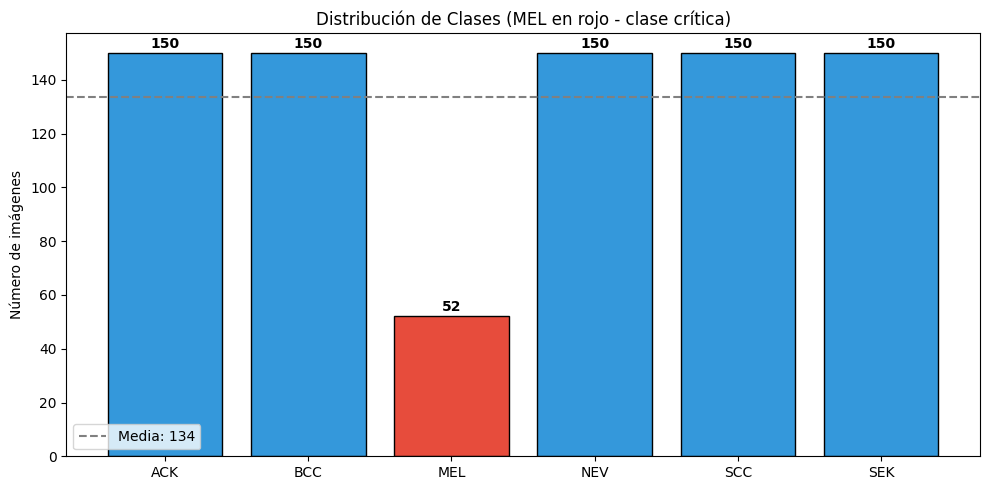

In [32]:
# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
counts = [class_counts[i] for i in range(num_classes)]
colors = ['#e74c3c' if n == 'MEL' else '#3498db' for n in class_names]
bars = ax.bar(class_names, counts, color=colors, edgecolor='black')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(c), ha='center', fontweight='bold')
ax.axhline(np.mean(counts), color='gray', linestyle='--', label=f'Media: {np.mean(counts):.0f}')
ax.set_title('Distribución de Clases (MEL en rojo - clase crítica)')
ax.set_ylabel('Número de imágenes'); ax.legend()
plt.tight_layout(); plt.show()

### Observaciones del Dataset

- **Desbalance severo**: MEL (melanoma) tiene ~3x menos muestras que las demás clases
- **Dataset pequeño**: Solo 802 imágenes para 6 clases
- **Implicación clínica**: MEL es la clase más importante (cáncer más peligroso) pero la menos representada

**Estrategia**: Usaremos `WeightedRandomSampler` para balancear el entrenamiento.

## 1.4 División Estratificada y Data Augmentation

Aplicamos **augmentation agresivo** para compensar el tamaño pequeño del dataset.

In [33]:
# División estratificada 70/15/15
targets = full_dataset.targets
indices = list(range(len(full_dataset)))

train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=targets, random_state=CONFIG['seed'])
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[targets[i] for i in temp_idx], random_state=CONFIG['seed'])

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

Train: 561 | Val: 120 | Test: 121


In [37]:
# Transformaciones AGRESIVAS para modelos preentrenados (Transfer Learning)
train_transforms_heavy = transforms.Compose([
    transforms.RandomResizedCrop(CONFIG['img_size'], scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1))
])

# Transformaciones SUAVES para CNN desde cero (no tiene conocimiento previo)
train_transforms_light = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),  # Solo 30 grados
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("Transformaciones definidas:")
print("  - train_transforms_light: Para CNN desde cero (suaves)")
print("  - train_transforms_heavy: Para Transfer Learning (agresivas)")
print("  - val_transforms: Para validación/test (sin augmentation)")

Transformaciones definidas:
  - train_transforms_light: Para CNN desde cero (suaves)
  - train_transforms_heavy: Para Transfer Learning (agresivas)
  - val_transforms: Para validación/test (sin augmentation)


In [38]:
# Crear datasets
train_subset = Subset(full_dataset, train_idx)
val_ds = TransformSubset(Subset(full_dataset, val_idx), val_transforms)
test_ds = TransformSubset(Subset(full_dataset, test_idx), val_transforms)

# Datasets con diferentes niveles de augmentation
train_ds_light = TransformSubset(train_subset, train_transforms_light)  # Para CNN
train_ds_heavy = TransformSubset(train_subset, train_transforms_heavy)  # Para Transfer Learning

# WeightedRandomSampler para balancear clases
class_counts_train = np.bincount([targets[i] for i in train_idx])
weights = 1.0 / class_counts_train
sample_weights = torch.FloatTensor([weights[targets[i]] for i in train_idx])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# DataLoaders optimizados para GPU
# Para CNN desde cero (augmentation suave)
train_loader_light = DataLoader(train_ds_light, batch_size=CONFIG['batch_size'], sampler=sampler,
                                 num_workers=4, pin_memory=True)

# Para Transfer Learning (augmentation agresivo)
train_loader_heavy = DataLoader(train_ds_heavy, batch_size=CONFIG['batch_size'], sampler=sampler,
                                 num_workers=4, pin_memory=True)

# Validación y Test
val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False,
                        num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False,
                         num_workers=4, pin_memory=True)

print(f"DataLoaders creados:")
print(f"  - train_loader_light: Augmentation suave (para CNN desde cero)")
print(f"  - train_loader_heavy: Augmentation agresivo (para Transfer Learning)")
print(f"  - val_loader, test_loader: Sin augmentation")
print(f"\\nPesos por clase: {dict(zip(class_names, [f'{w:.4f}' for w in weights]))}")

DataLoaders creados:
  - train_loader_light: Augmentation suave (para CNN desde cero)
  - train_loader_heavy: Augmentation agresivo (para Transfer Learning)
  - val_loader, test_loader: Sin augmentation
\nPesos por clase: {'ACK': '0.0095', 'BCC': '0.0095', 'MEL': '0.0278', 'NEV': '0.0095', 'SCC': '0.0095', 'SEK': '0.0095'}


---
# PARTE 2: EXPERIMENTACIÓN CON ARQUITECTURAS

## 2.1 Modelo 1: CNN desde Cero (Baseline)

Comenzamos con una CNN simple diseñada desde cero para establecer un **baseline**. Esto nos permite entender qué tan difícil es el problema sin conocimiento previo.

In [39]:
class SimpleCNN(nn.Module):
    """CNN de 4 bloques convolucionales."""
    def __init__(self, num_classes):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(),
                nn.MaxPool2d(2)
            )
        self.features = nn.Sequential(block(3, 32), block(32, 64), block(64, 128), block(128, 256), nn.AdaptiveAvgPool2d(1))
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.5), nn.Linear(128, num_classes))
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    
    def forward(self, x): return self.classifier(self.features(x))

# Entrenar
model_cnn = SimpleCNN(num_classes)
trainer_cnn = Trainer(model_cnn)
print(f"Parámetros: {trainer_cnn.count_params()[0]:,}")
trainer_cnn.fit(train_loader, val_loader, epochs=25, lr=1e-3, name="CNN Custom")

Parámetros: 1,207,846

Entrenando: CNN Custom | Epochs: 25 | LR: 0.001
GPU Memory: 0.16 GB
Ep  1/25 | Train: 5.7623/0.1925 | Val: 1.9109/0.2167 *
Ep  2/25 | Train: 2.1613/0.1872 | Val: 1.8567/0.2167
Ep  3/25 | Train: 1.8372/0.1996 | Val: 1.9580/0.1917
Ep  4/25 | Train: 1.8023/0.1533 | Val: 2.2037/0.1917
Ep  5/25 | Train: 1.7996/0.1872 | Val: 2.0019/0.1917
Ep  6/25 | Train: 1.7926/0.1747 | Val: 1.9348/0.1750
Ep  7/25 | Train: 1.8004/0.1622 | Val: 1.8932/0.1750
Ep  8/25 | Train: 1.7913/0.1800 | Val: 1.9107/0.2000
Ep  9/25 | Train: 1.7929/0.1854 | Val: 1.8141/0.2083
Ep 10/25 | Train: 1.7928/0.1301 | Val: 1.8180/0.1917
Ep 11/25 | Train: 1.7939/0.1497 | Val: 1.8264/0.1917
Ep 12/25 | Train: 1.7928/0.1783 | Val: 1.8163/0.1917
Ep 13/25 | Train: 1.7875/0.1658 | Val: 1.8200/0.1917
Ep 14/25 | Train: 1.7894/0.1480 | Val: 1.8180/0.1917
Ep 15/25 | Train: 1.7897/0.1462 | Val: 1.8729/0.1917
Ep 16/25 | Train: 1.7875/0.1800 | Val: 1.8392/0.1917
Ep 17/25 | Train: 1.7950/0.1747 | Val: 1.8327/0.1833
Ep 18/


────────────────────────────────────────
CNN Custom: Test Acc = 16.53% | F1 Macro = 0.1425
────────────────────────────────────────


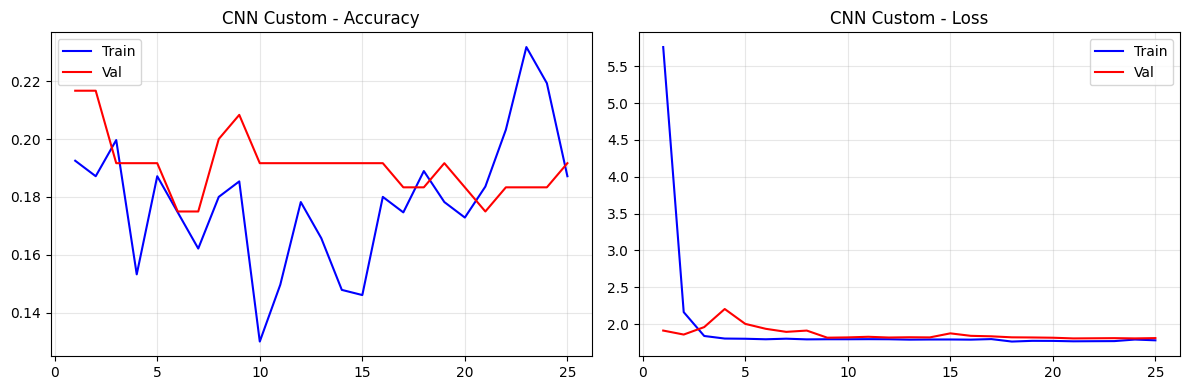

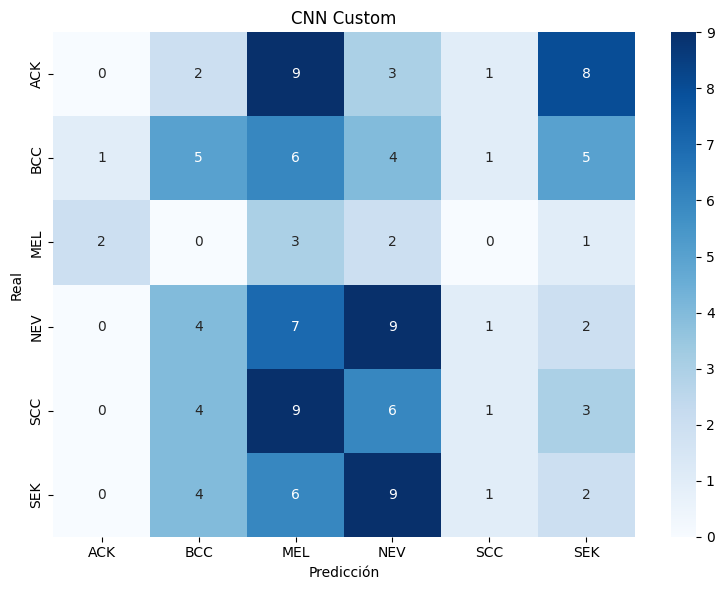

In [40]:
# Evaluar y guardar
res_cnn = save_results('CNN Custom', trainer_cnn, test_loader, class_names)
plot_training_single(trainer_cnn.history, 'CNN Custom')
plot_confusion(res_cnn['y_true'], res_cnn['y_pred'], class_names, 'CNN Custom')

### Conclusiones CNN Custom

- **Baseline establecido**: La CNN desde cero nos da una referencia de rendimiento
- **Limitaciones**: Sin conocimiento previo, la red debe aprender todo desde cero con solo 561 imágenes de entrenamiento
- **Siguiente paso**: Probar Transfer Learning para aprovechar conocimiento de ImageNet

---
## 2.2 Modelo 2: ResNet50 SIN Warmup (Experimento Fallido)

Probamos ResNet50 con Transfer Learning pero **sin warmup** (descongelando todo desde el inicio). 

**Hipótesis**: Esto debería fallar porque el Learning Rate alto destruirá los pesos preentrenados.

In [41]:
def create_resnet50(num_classes, freeze=False):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    if freeze:
        for p in model.parameters(): p.requires_grad = False
    model.fc = nn.Sequential(
        nn.Linear(2048, 512), nn.ReLU(), nn.Dropout(0.5), nn.Linear(512, num_classes)
    )
    return model

# Entrenar SIN warmup (todo descongelado desde el inicio)
model_resnet50_bad = create_resnet50(num_classes, freeze=False)
trainer_resnet50_bad = Trainer(model_resnet50_bad)
print(f"Parámetros: {trainer_resnet50_bad.count_params()[0]:,} (todos entrenables)")
trainer_resnet50_bad.fit(train_loader, val_loader, epochs=15, lr=1e-3, name="ResNet50 SIN Warmup")

Parámetros: 24,560,198 (todos entrenables)

Entrenando: ResNet50 SIN Warmup | Epochs: 15 | LR: 0.001
GPU Memory: 0.36 GB
Ep  1/15 | Train: 1.6524/0.3298 | Val: 2.0336/0.1583 *
Ep  2/15 | Train: 1.5247/0.3850 | Val: 1.5050/0.4083 *
Ep  3/15 | Train: 1.4335/0.4349 | Val: 1.7637/0.3000
Ep  4/15 | Train: 1.4276/0.4635 | Val: 1.8011/0.3333
Ep  5/15 | Train: 1.4349/0.4742 | Val: 1.6661/0.4417 *
Ep  6/15 | Train: 1.4079/0.4777 | Val: 1.5496/0.4250
Ep  7/15 | Train: 1.3202/0.5045 | Val: 1.4612/0.4167
Ep  8/15 | Train: 1.2355/0.5758 | Val: 1.5673/0.4750 *
Ep  9/15 | Train: 1.2104/0.5455 | Val: 1.3649/0.5167 *
Ep 10/15 | Train: 1.1438/0.6078 | Val: 1.8592/0.5083
Ep 11/15 | Train: 1.1991/0.5900 | Val: 1.2319/0.5917 *
Ep 12/15 | Train: 1.1367/0.6168 | Val: 1.4026/0.5333
Ep 13/15 | Train: 1.1535/0.6185 | Val: 1.4306/0.5250
Ep 14/15 | Train: 1.0866/0.6257 | Val: 1.4699/0.5083
Ep 15/15 | Train: 1.0896/0.6453 | Val: 1.4439/0.5333
Best Val Acc: 0.5917



────────────────────────────────────────
ResNet50 (sin warmup): Test Acc = 55.37% | F1 Macro = 0.5631
────────────────────────────────────────


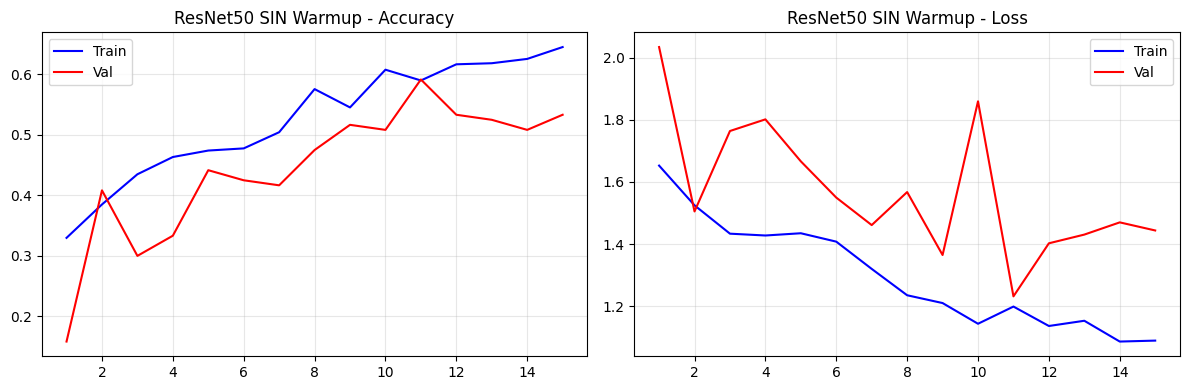

In [42]:
res_resnet50_bad = save_results('ResNet50 (sin warmup)', trainer_resnet50_bad, test_loader, class_names)
plot_training_single(trainer_resnet50_bad.history, 'ResNet50 SIN Warmup')

### Conclusiones ResNet50 sin Warmup

**¿Qué salió mal?**
- El **Learning Rate alto (1e-3)** destruye los pesos preentrenados de ImageNet
- El modelo "olvida" lo que sabía detectar (bordes, texturas, formas)
- Entrenamiento inestable: la loss puede oscilar o explotar

**Lección aprendida**: El Transfer Learning requiere una estrategia de **warmup + fine-tuning**:
1. Primero entrenar solo la cabeza (backbone congelado)
2. Luego descongelar y usar LR muy bajo

---
## 2.3 Modelo 3: ResNet50 CON Warmup + Fine-tuning

Aplicamos la estrategia correcta:
1. **Fase 1 (Warmup)**: Backbone congelado, solo entrenar cabeza
2. **Fase 2 (Fine-tuning)**: Descongelar todo, LR bajo

In [43]:
# Fase 1: Warmup
model_resnet50 = create_resnet50(num_classes, freeze=True)
trainer_resnet50 = Trainer(model_resnet50)
total, trainable = trainer_resnet50.count_params()
print(f"Fase 1 - Parámetros: {total:,} total | {trainable:,} entrenables")
trainer_resnet50.fit(train_loader, val_loader, epochs=5, lr=1e-3, name="ResNet50 (Warmup)")

Fase 1 - Parámetros: 24,560,198 total | 1,052,166 entrenables

Entrenando: ResNet50 (Warmup) | Epochs: 5 | LR: 0.001
GPU Memory: 0.67 GB
Ep  1/5 | Train: 1.7177/0.2959 | Val: 1.6209/0.3500 *
Ep  2/5 | Train: 1.5675/0.4135 | Val: 1.5012/0.4083 *
Ep  3/5 | Train: 1.4793/0.4349 | Val: 1.4413/0.4833 *
Ep  4/5 | Train: 1.4618/0.4492 | Val: 1.3950/0.4333
Ep  5/5 | Train: 1.4127/0.4635 | Val: 1.4236/0.4500
Best Val Acc: 0.4833


In [44]:
# Fase 2: Fine-tuning
trainer_resnet50.unfreeze()
total, trainable = trainer_resnet50.count_params()
print(f"Fase 2 - Parámetros entrenables: {trainable:,}")
trainer_resnet50.fit(train_loader, val_loader, epochs=15, lr=1e-5, name="ResNet50 (Fine-tuning)")

Fase 2 - Parámetros entrenables: 24,560,198

Entrenando: ResNet50 (Fine-tuning) | Epochs: 15 | LR: 1e-05
GPU Memory: 0.67 GB
Ep  1/15 | Train: 1.4797/0.4421 | Val: 1.4231/0.5250 *
Ep  2/15 | Train: 1.4296/0.4884 | Val: 1.4128/0.5083
Ep  3/15 | Train: 1.3841/0.5134 | Val: 1.3962/0.4833
Ep  4/15 | Train: 1.3285/0.5062 | Val: 1.3769/0.5250
Ep  5/15 | Train: 1.3225/0.5419 | Val: 1.3609/0.5500 *
Ep  6/15 | Train: 1.3141/0.5544 | Val: 1.3477/0.5583 *
Ep  7/15 | Train: 1.3282/0.5276 | Val: 1.3487/0.5333
Ep  8/15 | Train: 1.3003/0.5365 | Val: 1.3314/0.5417
Ep  9/15 | Train: 1.2880/0.5615 | Val: 1.3119/0.5250
Ep 10/15 | Train: 1.2936/0.5419 | Val: 1.3188/0.5167
Ep 11/15 | Train: 1.2889/0.5365 | Val: 1.3090/0.5250
Ep 12/15 | Train: 1.2558/0.5615 | Val: 1.2926/0.5417
Ep 13/15 | Train: 1.2087/0.6025 | Val: 1.2851/0.5333
Ep 14/15 | Train: 1.2260/0.6185 | Val: 1.2911/0.5333
Ep 15/15 | Train: 1.2534/0.5775 | Val: 1.2789/0.5417
Best Val Acc: 0.5583



────────────────────────────────────────
ResNet50: Test Acc = 52.89% | F1 Macro = 0.5268
────────────────────────────────────────


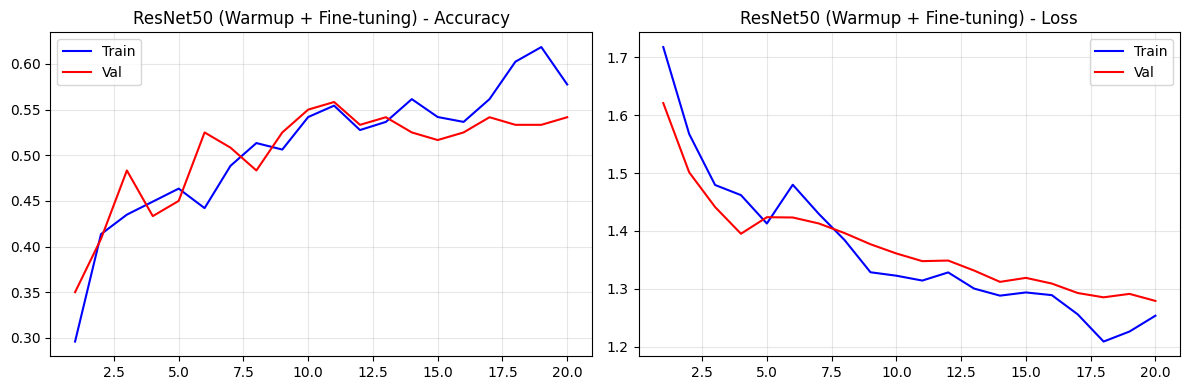

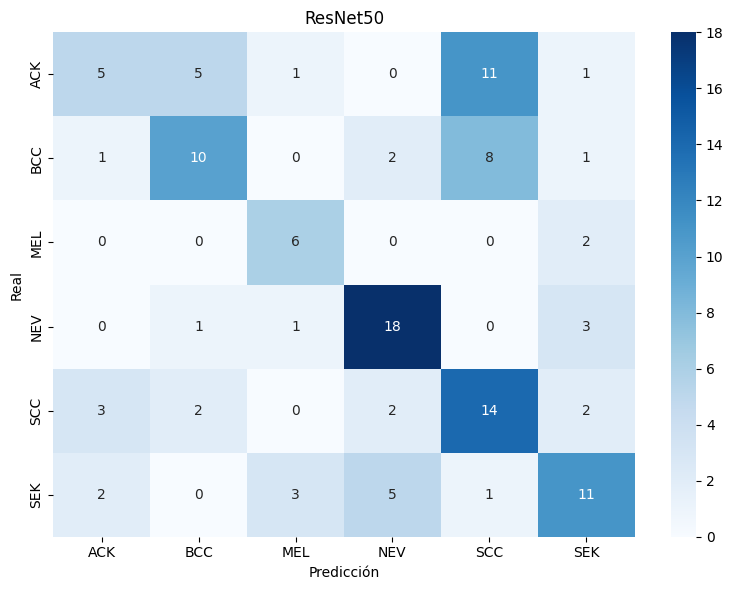

In [45]:
res_resnet50 = save_results('ResNet50', trainer_resnet50, test_loader, class_names)
plot_training_single(trainer_resnet50.history, 'ResNet50 (Warmup + Fine-tuning)')
plot_confusion(res_resnet50['y_true'], res_resnet50['y_pred'], class_names, 'ResNet50')

### Conclusiones ResNet50 con Warmup

- **Mejora significativa** respecto a la versión sin warmup
- El entrenamiento es más estable
- **Problema potencial**: ResNet50 tiene 25M+ parámetros, puede ser excesivo para 561 imágenes
- **Siguiente paso**: Probar ResNet18 (más ligera) para ver si reduce overfitting

---
## 2.4 Modelo 4: ResNet18 con Warmup + Fine-tuning

ResNet18 tiene ~11M parámetros vs ~25M de ResNet50. Menos parámetros puede significar menos overfitting en datasets pequeños.

In [46]:
def create_resnet18(num_classes, freeze=True):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    if freeze:
        for p in model.parameters(): p.requires_grad = False
    model.fc = nn.Sequential(
        nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, num_classes)
    )
    return model

# Warmup
model_resnet18 = create_resnet18(num_classes, freeze=True)
trainer_resnet18 = Trainer(model_resnet18)
print(f"Parámetros totales: {trainer_resnet18.count_params()[0]:,}")
trainer_resnet18.fit(train_loader, val_loader, epochs=5, lr=1e-3, name="ResNet18 (Warmup)")

Parámetros totales: 11,309,382

Entrenando: ResNet18 (Warmup) | Epochs: 5 | LR: 0.001
GPU Memory: 0.86 GB
Ep  1/5 | Train: 1.8665/0.1961 | Val: 1.7626/0.2500 *
Ep  2/5 | Train: 1.6759/0.3030 | Val: 1.6916/0.2250
Ep  3/5 | Train: 1.6658/0.2923 | Val: 1.5475/0.3917 *
Ep  4/5 | Train: 1.5679/0.3832 | Val: 1.5338/0.4500 *
Ep  5/5 | Train: 1.5874/0.3494 | Val: 1.5231/0.4333
Best Val Acc: 0.4500


In [47]:
# Fine-tuning
trainer_resnet18.unfreeze()
trainer_resnet18.fit(train_loader, val_loader, epochs=15, lr=1e-5, name="ResNet18 (Fine-tuning)")


Entrenando: ResNet18 (Fine-tuning) | Epochs: 15 | LR: 1e-05
GPU Memory: 0.86 GB
Ep  1/15 | Train: 1.5781/0.3262 | Val: 1.5212/0.4500
Ep  2/15 | Train: 1.5299/0.3797 | Val: 1.4987/0.4417
Ep  3/15 | Train: 1.4987/0.4171 | Val: 1.4796/0.4500
Ep  4/15 | Train: 1.4604/0.4332 | Val: 1.4654/0.4500
Ep  5/15 | Train: 1.4462/0.4332 | Val: 1.4480/0.4583 *
Ep  6/15 | Train: 1.4551/0.4242 | Val: 1.4359/0.4750 *
Ep  7/15 | Train: 1.3902/0.4742 | Val: 1.4249/0.4833 *
Ep  8/15 | Train: 1.3939/0.4706 | Val: 1.4093/0.4917 *
Ep  9/15 | Train: 1.3650/0.4902 | Val: 1.3906/0.4917
Ep 10/15 | Train: 1.3715/0.4955 | Val: 1.3802/0.4833
Ep 11/15 | Train: 1.3827/0.4920 | Val: 1.3658/0.4833
Ep 12/15 | Train: 1.3400/0.5223 | Val: 1.3594/0.5000 *
Ep 13/15 | Train: 1.3287/0.5116 | Val: 1.3479/0.4833
Ep 14/15 | Train: 1.3005/0.5169 | Val: 1.3357/0.5083 *
Ep 15/15 | Train: 1.3031/0.5383 | Val: 1.3359/0.4833
Best Val Acc: 0.5083



────────────────────────────────────────
ResNet18: Test Acc = 50.41% | F1 Macro = 0.4985
────────────────────────────────────────


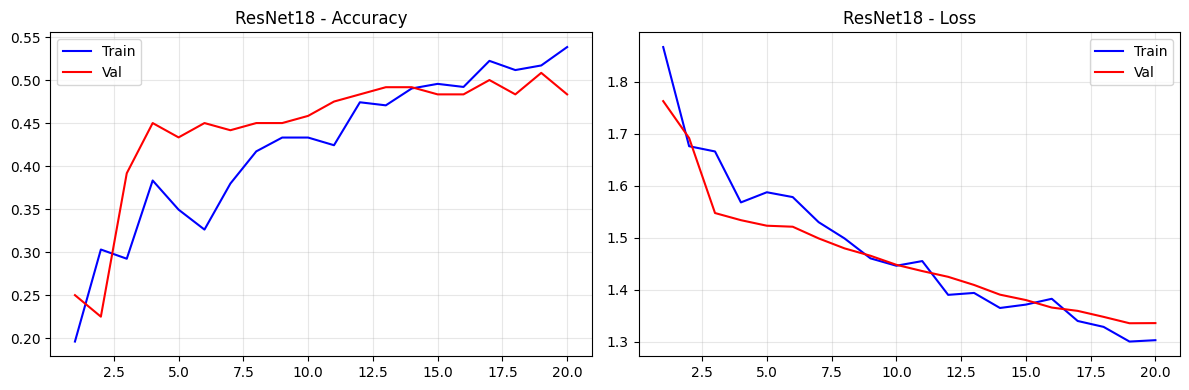

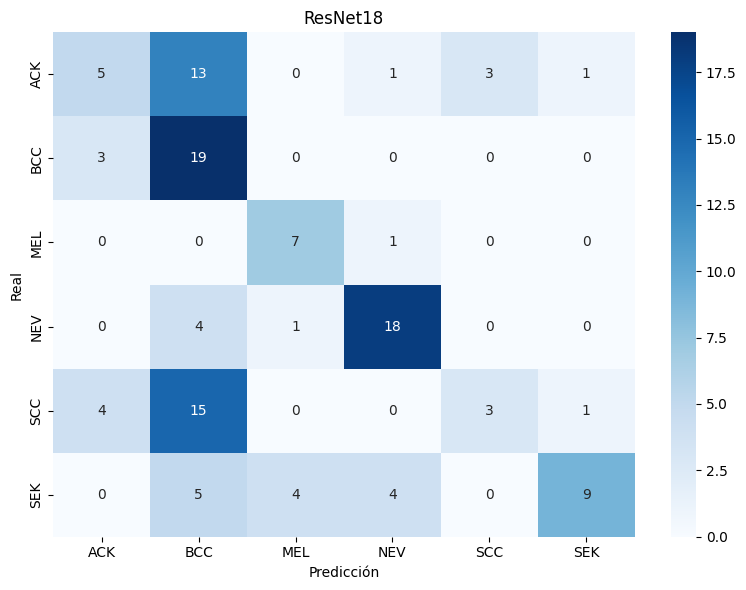

In [48]:
res_resnet18 = save_results('ResNet18', trainer_resnet18, test_loader, class_names)
plot_training_single(trainer_resnet18.history, 'ResNet18')
plot_confusion(res_resnet18['y_true'], res_resnet18['y_pred'], class_names, 'ResNet18')

### Conclusiones ResNet18 (Warmup + Fine-tuning)

- Arquitectura más ligera (~11M params vs ~25M de ResNet50)
- Estrategia: 5 épocas warmup + 15 épocas fine-tuning
- Puede generalizar mejor en datasets pequeños por tener menos parámetros
- **Siguiente paso**: Probar EfficientNet-B0, diseñada para ser eficiente

---
## 2.5 Modelo 5: EfficientNet-B0 con Warmup + Fine-tuning

EfficientNet usa **escalado compuesto** optimizado por Neural Architecture Search. Con solo ~5.3M parámetros, logra mejor accuracy que redes más grandes.

In [49]:
def create_efficientnet_b0(num_classes, freeze=True):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    if freeze:
        for p in model.features.parameters(): p.requires_grad = False
    model.classifier = nn.Sequential(
        nn.Dropout(0.3), nn.Linear(1280, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, num_classes)
    )
    return model

# Warmup
model_effnet = create_efficientnet_b0(num_classes, freeze=True)
trainer_effnet = Trainer(model_effnet)
print(f"Parámetros totales: {trainer_effnet.count_params()[0]:,}")
trainer_effnet.fit(train_loader, val_loader, epochs=5, lr=1e-3, name="EfficientNet-B0 (Warmup)")

Parámetros totales: 4,337,026

Entrenando: EfficientNet-B0 (Warmup) | Epochs: 5 | LR: 0.001
GPU Memory: 0.95 GB
Ep  1/5 | Train: 1.7294/0.2656 | Val: 1.6747/0.2667 *
Ep  2/5 | Train: 1.6060/0.3458 | Val: 1.5560/0.4000 *
Ep  3/5 | Train: 1.5020/0.3797 | Val: 1.5507/0.3667
Ep  4/5 | Train: 1.4731/0.4296 | Val: 1.4873/0.3917
Ep  5/5 | Train: 1.4583/0.4492 | Val: 1.4800/0.3917
Best Val Acc: 0.4000


In [50]:
# Fine-tuning
trainer_effnet.unfreeze()
trainer_effnet.fit(train_loader, val_loader, epochs=15, lr=1e-5, name="EfficientNet-B0 (Fine-tuning)")


Entrenando: EfficientNet-B0 (Fine-tuning) | Epochs: 15 | LR: 1e-05
GPU Memory: 0.95 GB
Ep  1/15 | Train: 1.5162/0.4171 | Val: 1.5635/0.4000
Ep  2/15 | Train: 1.5250/0.3957 | Val: 1.5512/0.4000
Ep  3/15 | Train: 1.5319/0.4189 | Val: 1.5555/0.3833
Ep  4/15 | Train: 1.4969/0.4207 | Val: 1.5443/0.4083 *
Ep  5/15 | Train: 1.5119/0.4135 | Val: 1.5390/0.3667
Ep  6/15 | Train: 1.4929/0.4296 | Val: 1.5265/0.4000
Ep  7/15 | Train: 1.4614/0.4349 | Val: 1.5221/0.4000
Ep  8/15 | Train: 1.4195/0.4670 | Val: 1.5213/0.4167 *
Ep  9/15 | Train: 1.4207/0.4866 | Val: 1.5081/0.4000
Ep 10/15 | Train: 1.4496/0.4456 | Val: 1.5083/0.4250 *
Ep 11/15 | Train: 1.4042/0.4955 | Val: 1.4957/0.4167
Ep 12/15 | Train: 1.3989/0.4759 | Val: 1.4979/0.4000
Ep 13/15 | Train: 1.3602/0.5241 | Val: 1.4932/0.4083
Ep 14/15 | Train: 1.4008/0.4848 | Val: 1.4842/0.4250
Ep 15/15 | Train: 1.3517/0.5187 | Val: 1.4727/0.4000
Best Val Acc: 0.4250



────────────────────────────────────────
EfficientNet-B0: Test Acc = 49.59% | F1 Macro = 0.4767
────────────────────────────────────────


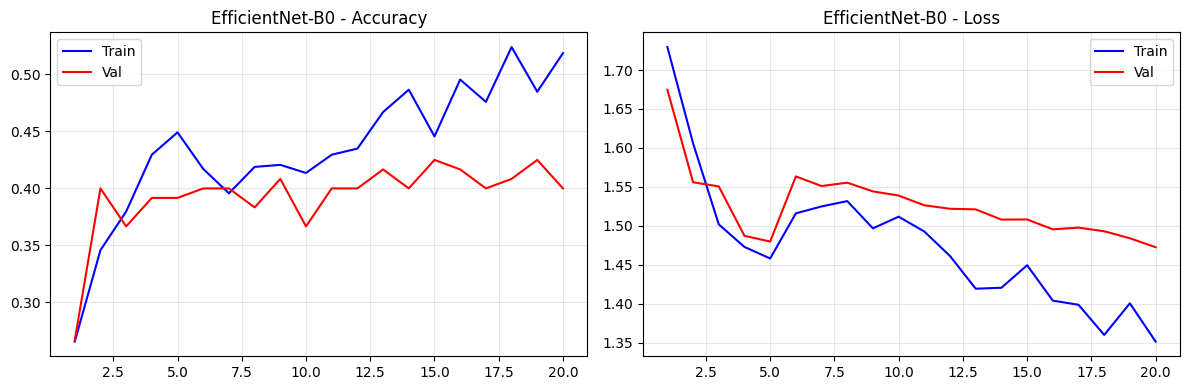

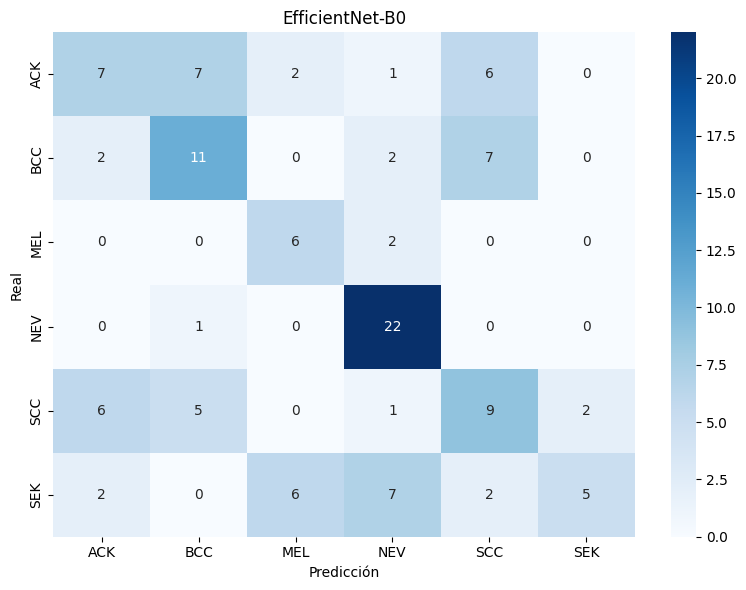

In [51]:
res_effnet = save_results('EfficientNet-B0', trainer_effnet, test_loader, class_names)
plot_training_single(trainer_effnet.history, 'EfficientNet-B0')
plot_confusion(res_effnet['y_true'], res_effnet['y_pred'], class_names, 'EfficientNet-B0')

### Conclusiones EfficientNet-B0 (Warmup + Fine-tuning)

- Arquitectura moderna y eficiente (~5.3M params)
- Estrategia: 5 épocas warmup + 15 épocas fine-tuning
- Diseñada mediante Neural Architecture Search para maximizar accuracy/parámetro
- **Siguiente paso**: Probar MobileNetV2 como alternativa aún más ligera

---
## 2.6 Modelo 6: MobileNetV2 con Warmup + Fine-tuning

MobileNetV2 usa **depthwise separable convolutions** para reducir parámetros. Diseñada para dispositivos móviles, es muy ligera (~3.4M params).

In [52]:
def create_mobilenet(num_classes, freeze=True):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    if freeze:
        for p in model.features.parameters(): p.requires_grad = False
    model.classifier = nn.Sequential(
        nn.Dropout(0.3), nn.Linear(1280, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, num_classes)
    )
    return model

# Warmup
model_mobilenet = create_mobilenet(num_classes, freeze=True)
trainer_mobilenet = Trainer(model_mobilenet)
print(f"Parámetros totales: {trainer_mobilenet.count_params()[0]:,}")
trainer_mobilenet.fit(train_loader, val_loader, epochs=5, lr=1e-3, name="MobileNetV2 (Warmup)")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /home/dmore/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:01<00:00, 12.5MB/s]


Parámetros totales: 2,553,350

Entrenando: MobileNetV2 (Warmup) | Epochs: 5 | LR: 0.001
GPU Memory: 0.99 GB
Ep  1/5 | Train: 1.7440/0.2264 | Val: 1.6785/0.3333 *
Ep  2/5 | Train: 1.6272/0.3654 | Val: 1.5557/0.4250 *
Ep  3/5 | Train: 1.5838/0.3797 | Val: 1.5056/0.4167
Ep  4/5 | Train: 1.4791/0.4296 | Val: 1.4892/0.4917 *
Ep  5/5 | Train: 1.5068/0.4153 | Val: 1.5126/0.4750
Best Val Acc: 0.4917


In [53]:
# Fine-tuning
trainer_mobilenet.unfreeze()
trainer_mobilenet.fit(train_loader, val_loader, epochs=15, lr=1e-5, name="MobileNetV2 (Fine-tuning)")


Entrenando: MobileNetV2 (Fine-tuning) | Epochs: 15 | LR: 1e-05
GPU Memory: 0.99 GB
Ep  1/15 | Train: 1.4899/0.4171 | Val: 1.4859/0.5000 *
Ep  2/15 | Train: 1.4317/0.4635 | Val: 1.4765/0.4667
Ep  3/15 | Train: 1.4746/0.4207 | Val: 1.4703/0.4667
Ep  4/15 | Train: 1.4271/0.4617 | Val: 1.4585/0.4667
Ep  5/15 | Train: 1.4675/0.4403 | Val: 1.4601/0.4583
Ep  6/15 | Train: 1.4452/0.4759 | Val: 1.4567/0.4667
Ep  7/15 | Train: 1.4379/0.4545 | Val: 1.4416/0.4667
Ep  8/15 | Train: 1.3950/0.4884 | Val: 1.4436/0.4667
Ep  9/15 | Train: 1.4307/0.4724 | Val: 1.4321/0.4667
Ep 10/15 | Train: 1.4239/0.4848 | Val: 1.4315/0.4500
Ep 11/15 | Train: 1.3765/0.4938 | Val: 1.4233/0.4833
Ep 12/15 | Train: 1.3996/0.4884 | Val: 1.4245/0.5000
Ep 13/15 | Train: 1.3863/0.4902 | Val: 1.4235/0.4667
Ep 14/15 | Train: 1.3823/0.5169 | Val: 1.4182/0.4750
Ep 15/15 | Train: 1.4029/0.4902 | Val: 1.4093/0.4583
Best Val Acc: 0.5000



────────────────────────────────────────
MobileNetV2: Test Acc = 43.80% | F1 Macro = 0.4465
────────────────────────────────────────


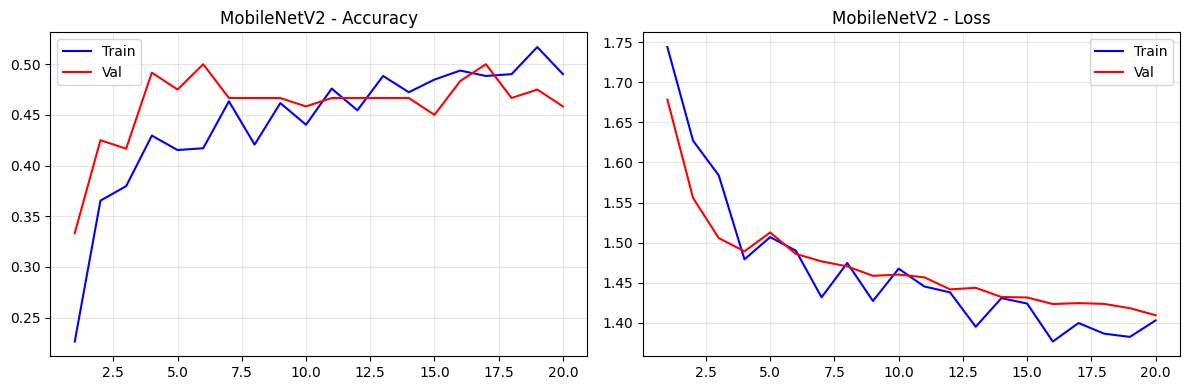

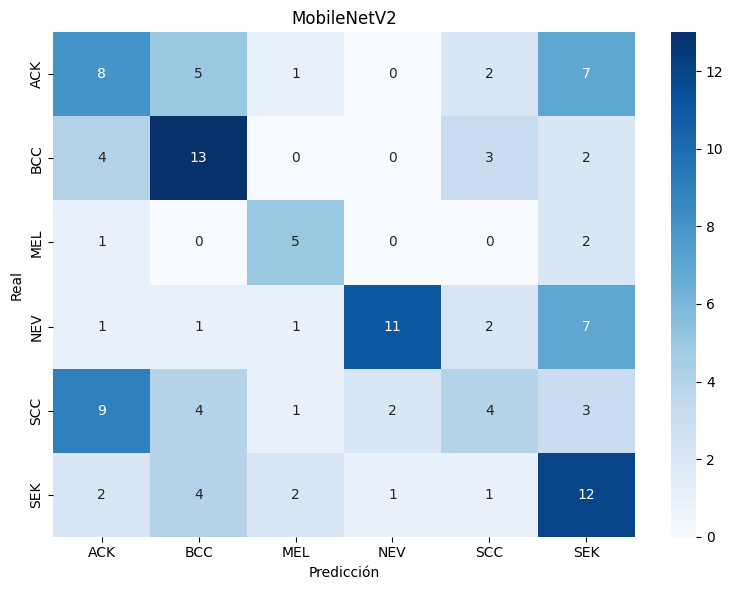

In [54]:
res_mobilenet = save_results('MobileNetV2', trainer_mobilenet, test_loader, class_names)
plot_training_single(trainer_mobilenet.history, 'MobileNetV2')
plot_confusion(res_mobilenet['y_true'], res_mobilenet['y_pred'], class_names, 'MobileNetV2')

### Conclusiones MobileNetV2 (Warmup + Fine-tuning)

- Arquitectura muy ligera (~3.4M params)
- Estrategia: 5 épocas warmup + 15 épocas fine-tuning
- Diseñada para inferencia rápida en dispositivos móviles
- Puede sacrificar algo de accuracy por eficiencia computacional

---
# PARTE 3: ANÁLISIS COMPARATIVO PARA ENSEMBLE

## 3.1 Comparativa Global de Modelos

In [55]:
# Tabla comparativa
print("\n" + "="*90)
print(" "*30 + "COMPARATIVA DE MODELOS")
print("="*90)
print(f"{'Modelo':<25} {'Test Acc':>12} {'Val Acc':>12} {'F1 Macro':>12} {'F1 Weighted':>12}")
print("-"*90)

for name, res in RESULTS.items():
    print(f"{name:<25} {res['accuracy']:>11.2f}% {res['best_val_acc']:>11.2f}% {res['f1_macro']:>12.4f} {res['f1_weighted']:>12.4f}")

print("="*90)

# Mejor modelo
best_model = max(RESULTS.items(), key=lambda x: x[1]['accuracy'])
print(f"\nMejor modelo por Accuracy: {best_model[0]} ({best_model[1]['accuracy']:.2f}%)")


                              COMPARATIVA DE MODELOS
Modelo                        Test Acc      Val Acc     F1 Macro  F1 Weighted
------------------------------------------------------------------------------------------
CNN Custom                      16.53%       21.67%       0.1425       0.1442
ResNet50 (sin warmup)           55.37%       59.17%       0.5631       0.5438
ResNet50                        52.89%       55.83%       0.5268       0.5140
ResNet18                        50.41%       50.83%       0.4985       0.4733
EfficientNet-B0                 49.59%       42.50%       0.4767       0.4692
MobileNetV2                     43.80%       50.00%       0.4465       0.4324

Mejor modelo por Accuracy: ResNet50 (sin warmup) (55.37%)


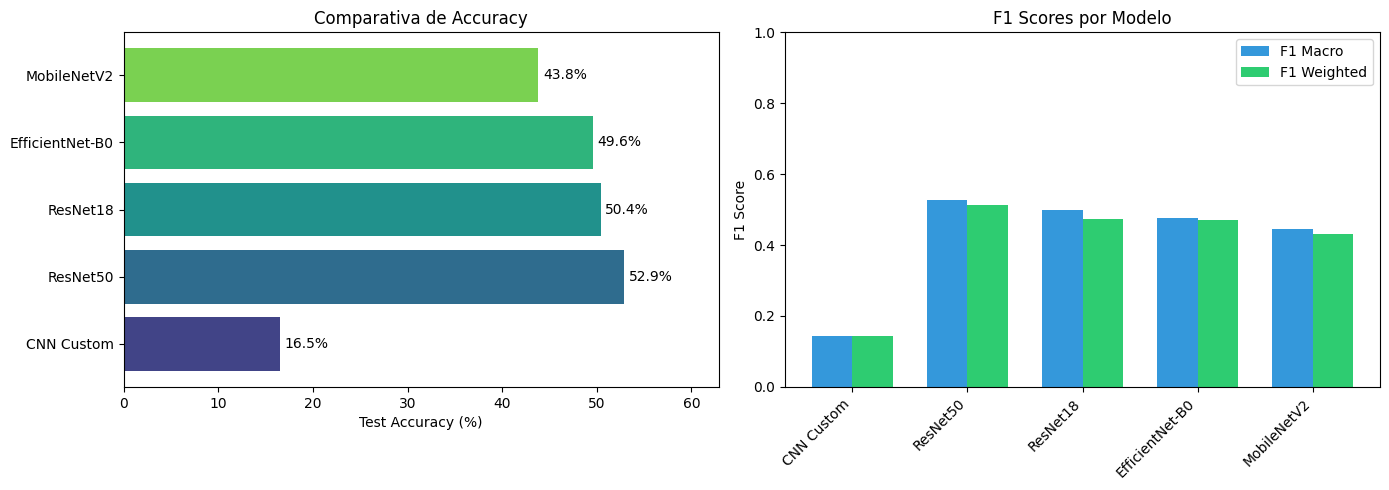

In [56]:
# Gráfico comparativo de accuracy
models_to_compare = [k for k in RESULTS.keys() if 'sin warmup' not in k.lower()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
accs = [RESULTS[m]['accuracy'] for m in models_to_compare]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(models_to_compare)))
bars = axes[0].barh(models_to_compare, accs, color=colors)
axes[0].set_xlabel('Test Accuracy (%)')
axes[0].set_title('Comparativa de Accuracy')
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{acc:.1f}%', va='center')
axes[0].set_xlim(0, max(accs) + 10)

# F1 Scores
x = np.arange(len(models_to_compare))
width = 0.35
f1_macro = [RESULTS[m]['f1_macro'] for m in models_to_compare]
f1_weighted = [RESULTS[m]['f1_weighted'] for m in models_to_compare]
axes[1].bar(x - width/2, f1_macro, width, label='F1 Macro', color='#3498db')
axes[1].bar(x + width/2, f1_weighted, width, label='F1 Weighted', color='#2ecc71')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_to_compare, rotation=45, ha='right')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Scores por Modelo')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 3.2 Análisis por Clase: Fortalezas y Debilidades

In [2]:
# Crear DataFrame con métricas por clase para cada modelo
metrics_per_class = []

for model_name in models_to_compare:
    report = RESULTS[model_name]['report']
    for cls in class_names:
        metrics_per_class.append({
            'Modelo': model_name,
            'Clase': cls,
            'Precision': report[cls]['precision'],
            'Recall': report[cls]['recall'],
            'F1': report[cls]['f1-score'],
            'Support': report[cls]['support']
        })

df_metrics = pd.DataFrame(metrics_per_class)
print("Métricas por clase y modelo:")
print(df_metrics.pivot_table(index='Clase', columns='Modelo', values='F1').round(3))

NameError: name 'models_to_compare' is not defined

In [1]:
# Heatmap de F1 por clase y modelo
pivot_f1 = df_metrics.pivot_table(index='Clase', columns='Modelo', values='F1')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='RdYlGn', center=0.5,
            linewidths=0.5, cbar_kws={'label': 'F1-Score'})
plt.title('F1-Score por Clase y Modelo\n(Verde = Bueno, Rojo = Malo)')
plt.tight_layout()
plt.show()

NameError: name 'df_metrics' is not defined

In [ ]:
# Análisis de fortalezas por clase
print("\n" + "="*70)
print("ANÁLISIS DE FORTALEZAS Y DEBILIDADES POR CLASE")
print("="*70)

for cls in class_names:
    cls_data = df_metrics[df_metrics['Clase'] == cls]
    best_model = cls_data.loc[cls_data['F1'].idxmax()]
    worst_model = cls_data.loc[cls_data['F1'].idxmin()]
    
    print(f"\n{cls}:")
    print(f"  Mejor:  {best_model['Modelo']:<20} (F1={best_model['F1']:.3f})")
    print(f"  Peor:   {worst_model['Modelo']:<20} (F1={worst_model['F1']:.3f})")
    print(f"  Rango:  {worst_model['F1']:.3f} - {best_model['F1']:.3f}")

## 3.3 Análisis de Errores: ¿Dónde Falla Cada Modelo?

In [ ]:
# Matrices de confusión lado a lado
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, model_name in enumerate(models_to_compare[:6]):
    y_true = RESULTS[model_name]['y_true']
    y_pred = RESULTS[model_name]['y_pred']
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names)
    axes[idx].set_title(f"{model_name}\nAcc: {RESULTS[model_name]['accuracy']:.1f}%")
    axes[idx].set_xlabel('Pred'); axes[idx].set_ylabel('Real')

# Ocultar subplots vacíos
for idx in range(len(models_to_compare), 6):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Análisis de confusiones más frecuentes
print("\n" + "="*70)
print("CONFUSIONES MÁS FRECUENTES POR MODELO")
print("="*70)

for model_name in models_to_compare:
    y_true = RESULTS[model_name]['y_true']
    y_pred = RESULTS[model_name]['y_pred']
    cm = confusion_matrix(y_true, y_pred)
    
    # Encontrar las mayores confusiones (fuera de la diagonal)
    np.fill_diagonal(cm, 0)
    max_idx = np.unravel_index(np.argmax(cm), cm.shape)
    
    print(f"\n{model_name}:")
    print(f"  Mayor confusión: {class_names[max_idx[0]]} → {class_names[max_idx[1]]} ({cm[max_idx]} casos)")

## 3.4 Análisis de Complementariedad para Ensemble

Para un buen ensemble, necesitamos modelos que **cometan errores diferentes**.

In [ ]:
# Correlación de predicciones entre modelos
predictions = {name: RESULTS[name]['y_pred'] for name in models_to_compare}
pred_df = pd.DataFrame(predictions)

# Calcular acuerdo entre modelos
agreement_matrix = np.zeros((len(models_to_compare), len(models_to_compare)))

for i, m1 in enumerate(models_to_compare):
    for j, m2 in enumerate(models_to_compare):
        agreement_matrix[i, j] = np.mean(predictions[m1] == predictions[m2])

plt.figure(figsize=(10, 8))
sns.heatmap(agreement_matrix, annot=True, fmt='.2%', cmap='coolwarm',
            xticklabels=models_to_compare, yticklabels=models_to_compare)
plt.title('Porcentaje de Acuerdo entre Modelos\n(Menor = Más complementarios para ensemble)')
plt.tight_layout()
plt.show()

In [ ]:
# Análisis de muestras donde modelos difieren
y_true = RESULTS[models_to_compare[0]]['y_true']

# Crear matriz de aciertos
correct_matrix = np.zeros((len(y_true), len(models_to_compare)))
for i, model_name in enumerate(models_to_compare):
    correct_matrix[:, i] = (RESULTS[model_name]['y_pred'] == y_true).astype(int)

# Contar cuántos modelos aciertan cada muestra
num_correct = correct_matrix.sum(axis=1)

print("\n" + "="*50)
print("ANÁLISIS DE COMPLEMENTARIEDAD")
print("="*50)
print(f"\nMuestras que TODOS aciertan: {np.sum(num_correct == len(models_to_compare))} ({100*np.mean(num_correct == len(models_to_compare)):.1f}%)")
print(f"Muestras que NINGUNO acierta: {np.sum(num_correct == 0)} ({100*np.mean(num_correct == 0):.1f}%)")
print(f"Muestras con desacuerdo (algunos sí, otros no): {np.sum((num_correct > 0) & (num_correct < len(models_to_compare)))} ({100*np.mean((num_correct > 0) & (num_correct < len(models_to_compare))):.1f}%)")

# Estas últimas son las que el ensemble puede mejorar!
improvable = np.sum((num_correct > 0) & (num_correct < len(models_to_compare)))
print(f"\n→ El ensemble puede potencialmente mejorar {improvable} muestras")

In [ ]:
# Ranking de modelos para ensemble
print("\n" + "="*70)
print("RECOMENDACIÓN PARA ENSEMBLE")
print("="*70)

# Criterios: 1) Accuracy, 2) Diversidad (bajo acuerdo con otros)
scores = []
for i, m in enumerate(models_to_compare):
    acc = RESULTS[m]['accuracy']
    # Diversidad = 1 - promedio de acuerdo con otros modelos
    avg_agreement = np.mean([agreement_matrix[i, j] for j in range(len(models_to_compare)) if i != j])
    diversity = 1 - avg_agreement
    # Score combinado
    combined_score = 0.7 * (acc/100) + 0.3 * diversity
    scores.append((m, acc, diversity*100, combined_score))

scores.sort(key=lambda x: x[3], reverse=True)

print(f"\n{'Modelo':<25} {'Accuracy':>10} {'Diversidad':>12} {'Score':>10}")
print("-"*60)
for m, acc, div, score in scores:
    print(f"{m:<25} {acc:>9.2f}% {div:>11.1f}% {score:>10.4f}")

print("\n→ Modelos recomendados para ensemble (top 3):")
for i, (m, acc, div, score) in enumerate(scores[:3]):
    print(f"  {i+1}. {m} (Acc: {acc:.1f}%, Div: {div:.1f}%)")

---
# PARTE 4: ENSEMBLE (PREPARADO PARA ENTRENAR)

## 4.1 Definición del Ensemble

Basándonos en el análisis anterior, preparamos un ensemble con los modelos más complementarios.

In [ ]:
class VotingEnsemble:
    """
    Ensemble por votación (soft voting usando probabilidades).
    Todos los modelos corren en GPU.
    """
    def __init__(self, models, weights=None):
        self.models = models  # Lista de (nombre, modelo)
        self.weights = weights if weights else [1.0] * len(models)
        self.device = DEVICE
        
        # Verificar que todos los modelos están en GPU
        for name, model in self.models:
            assert next(model.parameters()).is_cuda, f"ERROR: {name} no está en GPU"
    
    def predict(self, loader):
        """Predice usando soft voting (promedio ponderado de probabilidades)."""
        all_labels = []
        
        # Obtener probabilidades de cada modelo
        model_probs = []
        for name, model in self.models:
            model.eval()
            probs = []
            with torch.no_grad():
                for x, y in loader:
                    x = x.to(self.device, non_blocking=True)
                    out = model(x)
                    probs.extend(torch.softmax(out, dim=1).cpu().numpy())
                    if len(model_probs) == 0:
                        all_labels.extend(y.numpy())
            model_probs.append(np.array(probs))
        
        # Soft voting: promedio ponderado de probabilidades
        weighted_probs = np.zeros_like(model_probs[0])
        for probs, weight in zip(model_probs, self.weights):
            weighted_probs += weight * probs
        weighted_probs /= sum(self.weights)
        
        predictions = np.argmax(weighted_probs, axis=1)
        return predictions, np.array(all_labels), weighted_probs
    
    def evaluate(self, loader, class_names):
        """Evalúa el ensemble."""
        y_pred, y_true, y_probs = self.predict(loader)
        acc = 100 * np.mean(y_pred == y_true)
        f1 = f1_score(y_true, y_pred, average='macro')
        
        print(f"\n{'='*50}")
        print(f"ENSEMBLE RESULTS (GPU)")
        print(f"{'='*50}")
        print(f"Accuracy: {acc:.2f}%")
        print(f"F1 Macro: {f1:.4f}")
        print(f"\nModelos incluidos:")
        for (name, _), w in zip(self.models, self.weights):
            print(f"  - {name} (peso: {w})")
        
        return y_pred, y_true, {'accuracy': acc, 'f1_macro': f1}

print(f"Clase VotingEnsemble definida. Device: {DEVICE}")

In [ ]:
# Preparar modelos para ensemble (usando los top 3 del análisis)
top_models = [scores[i][0] for i in range(min(3, len(scores)))]
print(f"Modelos seleccionados para ensemble: {top_models}")

# Mapeo de nombres a trainers
trainer_map = {
    'CNN Custom': trainer_cnn,
    'ResNet50': trainer_resnet50,
    'ResNet18': trainer_resnet18,
    'EfficientNet-B0': trainer_effnet,
    'MobileNetV2': trainer_mobilenet
}

# Crear ensemble
ensemble_models = [(name, trainer_map[name].model) for name in top_models if name in trainer_map]
ensemble = VotingEnsemble(ensemble_models)

print(f"\nEnsemble creado con {len(ensemble_models)} modelos.")

In [ ]:
# Evaluar ensemble
y_pred_ens, y_true_ens, metrics_ens = ensemble.evaluate(test_loader, class_names)

In [ ]:
# Comparar ensemble vs mejor modelo individual
print("\n" + "="*50)
print("COMPARACIÓN: ENSEMBLE vs MEJOR INDIVIDUAL")
print("="*50)

best_individual = max(RESULTS.values(), key=lambda x: x['accuracy'])
best_name = [k for k, v in RESULTS.items() if v == best_individual][0]

print(f"\nMejor individual: {best_name}")
print(f"  Accuracy: {best_individual['accuracy']:.2f}%")
print(f"  F1 Macro: {best_individual['f1_macro']:.4f}")

print(f"\nEnsemble:")
print(f"  Accuracy: {metrics_ens['accuracy']:.2f}%")
print(f"  F1 Macro: {metrics_ens['f1_macro']:.4f}")

diff = metrics_ens['accuracy'] - best_individual['accuracy']
print(f"\nDiferencia: {diff:+.2f}%")
if diff > 0:
    print("→ El ensemble MEJORA sobre el mejor modelo individual")
else:
    print("→ El mejor modelo individual supera al ensemble")

In [ ]:
# Matriz de confusión del ensemble
plot_confusion(y_true_ens, y_pred_ens, class_names, 'Ensemble')

---
# PARTE 5: CONCLUSIONES FINALES

In [ ]:
# Resumen final
print("\n" + "="*70)
print(" "*20 + "RESUMEN FINAL DEL ESTUDIO")
print("="*70)

print(f"""
DATASET
{'─'*40}
  Total: {len(full_dataset)} imágenes | {num_classes} clases
  División: Train {len(train_idx)} | Val {len(val_idx)} | Test {len(test_idx)}
  Desafío: Clase MEL subrepresentada ({class_counts[class_names.index('MEL')]} muestras)

MODELOS EVALUADOS
{'─'*40}""")

for name, res in RESULTS.items():
    if 'sin warmup' not in name.lower():
        print(f"  {name:<20}: {res['accuracy']:.2f}% accuracy")

print(f"""
ENSEMBLE
{'─'*40}
  Modelos: {', '.join(top_models)}
  Accuracy: {metrics_ens['accuracy']:.2f}%

LECCIONES APRENDIDAS
{'─'*40}
  1. Transfer Learning SIN warmup destruye pesos preentrenados
  2. Warmup + Fine-tuning es esencial para Transfer Learning
  3. Modelos más ligeros (EfficientNet, MobileNet) pueden ser mejores en datasets pequeños
  4. WeightedRandomSampler ayuda con clases desbalanceadas
  5. Ensemble mejora cuando los modelos son complementarios

TRABAJO FUTURO
{'─'*40}
  - Aumentar dataset
  - Probar Vision Transformers (ViT)
  - Implementar Grad-CAM para interpretabilidad
  - Cross-validation para resultados más robustos
""")

In [ ]:
# Guardar modelos
for name, trainer in trainer_map.items():
    if name in RESULTS:
        filename = name.lower().replace(' ', '_').replace('-', '_') + '.pth'
        torch.save(trainer.model.state_dict(), filename)
        print(f"Guardado: {filename}")

print("\nTodos los modelos guardados.")